# Reproducing the *C. elegans* spatial code

[Armingol et al. (2022)](https://doi.org/10.1371/journal.pcbi.1010715) searched for the
ligand-receptor pairs whose cell-cell interaction scores best explain the **physical distances**
between the cells of the whole animal, using a digital 3D map as the reference. This notebook runs
that analysis with `cell2cell.analysis.optimize_lr_pairs`, compares the result against the pairs the
paper reports, and reproduces its functional enrichment of the selected list.

The data lives in
[LewisLabUCSD/Celegans-cell2cell](https://github.com/LewisLabUCSD/Celegans-cell2cell) and pandas
reads it straight from the URL, so everything below runs as it is.

For an introduction to the method on data where the answer is known in advance, see
[Identifying a spatial code of ligand-receptor pairs](./Genetic-Algorithm-LR-Selection).

**Requirements.** `pip install cell2cell[ga]`

In [1]:
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.spatial
import scipy.stats
from statsmodels.stats.multitest import multipletests

import cell2cell as c2c

%matplotlib inline

/private/tmp/claude-503/-Users-eg22-Repos-cell2cell/fa1914c8-fe56-40d2-b837-7db6feb472f8/scratchpad/venv-ci312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The data



In [2]:
BASE = ('https://raw.githubusercontent.com/LewisLabUCSD/'
        'Celegans-cell2cell/master/data/')

celegans_rnaseq = c2c.io.load_rnaseq(
    rnaseq_file=BASE + 'RNA-Seq/Celegans_RNASeqData_Cell.xlsx',
    gene_column='gene_id', drop_nangenes=True, log_transformation=False,
    format='auto', verbose=False)

celegans_lr = c2c.io.load_ppi(
    ppi_file=BASE + 'PPI-Networks/Celegans-Curated-LR-pairs.xlsx',
    interaction_columns=('Ligand_WB', 'Receptor_WB'),
    rnaseq_genes=list(celegans_rnaseq.index), format='auto', verbose=False)

physical_distances = pd.read_csv(
    BASE + 'Digital-3D-Map/Celegans_Physical_Distances_Min.csv', index_col=0)

print('expression      :', celegans_rnaseq.shape, '(genes x cells)')
print('LR pairs        :', len(celegans_lr))
print('cells in the map:', physical_distances.shape[0])

expression      : (19391, 27) (genes x cells)
LR pairs        : 245
cells in the map: 22


The curated table carries more than the identifiers: a **gene symbol** for each partner and an
**LR function** for each pair. Symbols are what make the results readable, so we attach them once
here and use them throughout.

In [3]:
curated = pd.read_excel(BASE + 'PPI-Networks/Celegans-Curated-LR-pairs.xlsx')

# `remove_ppi_bidirectionality` can flip a pair, so look each one up both ways round
# and swap the annotation back when it was found reversed.
_curated = {(a, b): (ls, rs, fn) for a, b, ls, rs, fn in
            curated[['Ligand_WB', 'Receptor_WB', 'Ligand_symbol',
                     'Receptor_symbol', 'LR Function']].values}

def annotate(frame, a='A', b='B'):
    """Adds ligand/receptor symbols and the LR function to a frame of pairs."""
    records = []
    for x, y in frame[[a, b]].values:
        if (x, y) in _curated:
            ls, rs, fn = _curated[(x, y)]
        elif (y, x) in _curated:
            rs, ls, fn = _curated[(y, x)]        # found reversed: swap back
        else:
            ls = rs = fn = None
        records.append((ls, rs, fn))
    extra = pd.DataFrame(records, columns=['ligand', 'receptor', 'LR function'],
                         index=frame.index)
    return pd.concat([extra, frame.drop(columns=[a, b])], axis=1)

def pair_label(x, y):
    ls, rs, _ = _curated.get((x, y)) or tuple(reversed(_curated[(y, x)][:2])) + (None,)
    return '{}-{}'.format(ls, rs)

print('curated annotations for {} pairs'.format(len(curated)))
curated[['Ligand_WB', 'Receptor_WB', 'Ligand_symbol', 'Receptor_symbol', 'LR Function']].head()

curated annotations for 245 pairs


,Ligand_WB,Receptor_WB,Ligand_symbol,Receptor_symbol,LR Function
0,WBGene00000182,WBGene00004040,arf-1.2,pld-1,Cell adhesion
1,WBGene00000903,WBGene00004860,daf-7,sma-6,TGF-B signaling
2,WBGene00005647,WBGene00008779,srp-6,F14B4.1,Wnt signaling
3,WBGene00000074,WBGene00003930,adm-2,pat-3,Cell adhesion
4,WBGene00000074,WBGene00003929,adm-2,pat-2,Cell adhesion


## 2. Running the search

The study reported three variants, differing only in the score:

| Score | `communication_score` | `cci_score` | Notes |
|---|---|---|---|
| Bray-Curtis | `expression_thresholding` | `bray_curtis` | the main analysis |
| LR count | `expression_thresholding` | `count` | counts active pairs |
| ICELLNET | `expression_product` | `icellnet` | expression is `log2(x + 1)` transformed first |

We run the Bray-Curtis one, at the published settings: 200 individuals, 200 generations, a 10 TPM
threshold, and runs continuing until the objective improves by less than 2.5%.

In [4]:
celegans_setup = {'communication_score': 'expression_thresholding',
                  'cci_score': 'bray_curtis',
                  'cci_type': 'undirected'}

start = time.perf_counter()
celegans_results = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},   # 10 TPM
    analysis_setup=celegans_setup,
    population_size=200,
    generations=200,
    runs=None,                 # until the objective stops improving
    inc_percentage=0.025,
    random_state=888,
)
print('finished in {:.0f} s'.format(time.perf_counter() - start))

pd.DataFrame([{'run': k, 'objective': celegans_results[k]['obj_fn'],
               'pairs kept': celegans_results[k]['n_selected']}
              for k in sorted(celegans_results) if k.startswith('run')])

finished in 27 s


,run,objective,pairs kept
0,run1,0.498713,91
1,run2,0.623005,45
2,run3,0.642090,30
3,run4,0.647806,23


Each of the ~40,000 objective evaluations per run would otherwise have meant rebuilding the CCI
scores; the vectorized scorer is what brings the whole search down to seconds.

## 3. Comparing with the pairs published in the paper

The 37 pairs the paper selected for Bray-Curtis are in the same repository.

In [5]:
paper_pairs = pd.read_csv(BASE + 'PPI-Networks/Celegans-GA-BrayCurtis-Selected-LR-pairs.csv')

# `remove_ppi_bidirectionality` can flip a pair, so compare them as unordered
unordered = lambda a, b: frozenset((a, b))
paper_keys = {unordered(a, b) for a, b in
              paper_pairs[['Ligand_WB', 'Receptor_WB']].values}
our_keys = {unordered(a, b) for a, b in
            celegans_results['best_ppi_data'][['A', 'B']].values}

shared = our_keys & paper_keys
print('paper selection      : {} pairs'.format(len(paper_keys)))
print('our selection        : {} pairs'.format(len(our_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(our_keys - paper_keys)))
print('  of the paper\'s, we recovered {} ({:.0%})'
      .format(len(shared), len(shared) / len(paper_keys)))

paper selection      : 37 pairs
our selection        : 23 pairs
  also in the paper  : 21
  not in the paper   : 2
  of the paper's, we recovered 21 (57%)


### Integrating independent executions

The overlap is far beyond chance, but a single execution understates the agreement: a genetic
algorithm returns a *local* optimum, so different seeds land on different, largely overlapping sets.

The published analysis handled this by running the search many times independently and asking which
pairs are selected **together**. `executions=N` does that here — it repeats the search and adds three
things to the result:

- `selection_frequency` — how often each pair was chosen;
- `cooccurrence` — the Jaccard index between the selection patterns of every two pairs, i.e. how
  often they are chosen alongside each other;
- `consensus_ppi_data` — the pairs of the co-occurrence cluster whose members are most consistently
  co-selected. **This is the output to use.**

In [6]:
start = time.perf_counter()
consensus = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},
    analysis_setup=celegans_setup,
    population_size=200, generations=200, runs=None, inc_percentage=0.025,
    executions=30,             # thirty independent searches
    random_state=888,
)
print('30 executions in {:.0f} s'.format(time.perf_counter() - start))

annotate(consensus['selection_frequency']).head(12)

30 executions in 776 s


,ligand,receptor,LR function,frequency
23,cwn-1,mig-1,Wnt signaling,1.000000
189,smp-2,plx-1,Cell migration,0.966667
173,mnr-1,dma-1,Cell migration,0.933333
235,K05F1.5,dma-1,Cell migration,0.933333
16,col-99,ddr-1,Cell adhesion,0.800000
143,let-756,ver-1,Canonical RTK-Ras-ERK signaling,0.766667
11,cle-1,gpn-1,Cell adhesion,0.733333
224,wrt-5,ptc-1,Hedgehog signaling,0.700000
156,mab-20,plx-2,Cell migration,0.700000
46,dbl-1,sma-10,TGF-B signaling,0.666667


The co-occurrence matrix is what the consensus is built from. Clustering it separates a tight group
of pairs that keep being chosen together from a diffuse remainder.

In [7]:
sizes = {k: len(v) for k, v in consensus['consensus_clusters'].items()}
scores = {k: round(v, 3) for k, v in consensus['consensus_cluster_scores'].items()}
print('cluster sizes             :', sizes)
print('mean co-occurrence within :', scores)
print('\nconsensus selection: {} pairs'.format(len(consensus['consensus_ppi_data'])))

cluster sizes             : {np.int32(1): 75, np.int32(2): 31}
mean co-occurrence within : {np.int32(1): 0.076, np.int32(2): 0.359}

consensus selection: 31 pairs


In [8]:
consensus_keys = {unordered(a, b) for a, b in consensus['consensus_ppi_data'][['A', 'B']].values}
shared = consensus_keys & paper_keys
print('consensus selection  : {} pairs'.format(len(consensus_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(consensus_keys - paper_keys)))

annotate(consensus['consensus_ppi_data']).assign(
    in_paper=[unordered(a, b) in paper_keys
              for a, b in consensus['consensus_ppi_data'][['A', 'B']].values]) \
    .sort_values(['in_paper', 'ligand'], ascending=[False, True])

consensus selection  : 31 pairs
  also in the paper  : 29
  not in the paper   : 2


,ligand,receptor,LR function,score,in_paper
30,K05F1.5,dma-1,Cell migration,1.0,True
1,arg-1,lin-12,Notch signaling,1.0,True
2,cle-1,gpn-1,Cell adhesion,1.0,True
3,col-99,ddr-1,Cell adhesion,1.0,True
4,cwn-1,mig-1,Wnt signaling,1.0,True
5,daf-7,sma-6,TGF-B signaling,1.0,True
6,dbl-1,lon-2,TGF-B signaling,1.0,True
7,dbl-1,sma-10,TGF-B signaling,1.0,True
8,grd-11,ptc-1,Hedgehog signaling,1.0,True
10,hsp-1,F14B4.1,Stress response,1.0,True


The two criteria for *which* cluster to keep coincide on this data: the tight cluster is also the
smaller one. `cluster_selection='cooccurrence'` (the default) ranks by mean co-occurrence among a
cluster's own members, which is the property the analysis is actually after;
`cluster_selection='smallest'` is literally what the reference notebook did and is kept so the
published result can be reproduced exactly.

> **How many executions?** The clustering needs enough of them. Two pairs selected once, in the same
> execution, have a co-occurrence of 1.0 without that meaning anything, and with too few executions a
> cluster of such pairs outscores the reproducible one — with 10 executions this analysis returns 17
> pairs of which only 6 are the paper's, against 29 of 31 with 30. Use around 30 or more (the
> reference analysis used about a hundred), or set `min_frequency` to drop the rarely-chosen pairs.
> The frequency route below is the more forgiving of the two.

#### The simpler alternative: selection frequency

Rather than asking which pairs are chosen *together*, one can just keep those chosen *often*. The
reference notebook computed this too, using the 90th percentile of the frequency distribution. It is
easier to reason about, but it cannot separate two groups of pairs that are each self-consistent yet
rarely co-selected.

In [9]:
frequency = consensus['selection_frequency']['frequency'].values

for percentile in (80, 85, 90, 95):
    mask, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=percentile)
    kept = consensus['selection_frequency'].loc[mask]
    keys = {unordered(a, b) for a, b in kept[['A', 'B']].values}
    print('{}th percentile (frequency > {:.2f}): {:>2} pairs | {:>2} in the paper, {:>2} not'
          .format(percentile, threshold, len(keys), len(keys & paper_keys),
                  len(keys - paper_keys)))

80th percentile (frequency > 0.17): 41 pairs | 34 in the paper,  7 not
85th percentile (frequency > 0.20): 35 pairs | 33 in the paper,  2 not
90th percentile (frequency > 0.33): 24 pairs | 24 in the paper,  0 not
95th percentile (frequency > 0.56): 13 pairs | 13 in the paper,  0 not


Both routes converge on the same set of pairs — the ones the paper reports. Which to prefer depends
on the question: the co-occurrence clustering keeps groups of pairs that act together, while the
frequency threshold is a plain ranking of individual pairs.

The same steps are available on their own, for integrating results computed elsewhere:
`c2c.analysis.lr_selection_frequency`, `lr_cooccurrence`, `consensus_from_cooccurrence` and
`consensus_from_frequency`.

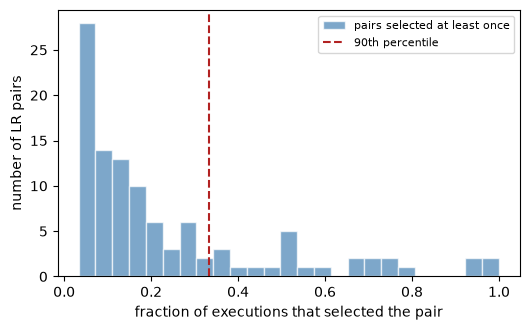

In [10]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.hist(frequency[frequency > 0], bins=25, color='steelblue', alpha=0.7,
        edgecolor='w', label='pairs selected at least once')
_, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=90)
ax.axvline(threshold, color='firebrick', ls='--', label='90th percentile')
ax.set_xlabel('fraction of executions that selected the pair')
ax.set_ylabel('number of LR pairs'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Which functions are the selected pairs enriched for?

The curated ligand-receptor table annotates every pair with an **LR function** — Wnt signalling,
cell adhesion, Hedgehog signalling, and so on. Asking which of those the search favours turns a list
of gene pairs into a statement about biology.

The paper's test, reproduced here:

1. every execution contributes its selected list;
2. for each execution, the **fraction** of its list falling in each function;
3. the background is the fraction of each function in the **full** pair list;
4. a Wilcoxon signed-rank test compares the distribution of per-execution fractions against that
   background, one-sided in each direction;
5. Benjamini-Hochberg across functions, reporting the smaller of the two adjusted values.

The test operates on the spread across executions, so **its resolution is bounded by how many there
are**: with *n* executions the smallest achievable one-sided p-value is `2**-n`. With 8 everything
floors around 0.004 and looks marginal; the 30 used here floor near `1e-9`, and the paper used about
a hundred.

In [11]:
# `functions` reuses the annotation built in section 1. The pool is what the masks
# are indexed against -- `selection_frequency` is sorted, so pairing that with the
# masks positionally would misalign them.
pool = consensus['pool']
functions = annotate(pool)['LR function']
print('pairs with a curated function: {} of {}'.format(functions.notna().sum(), len(functions)))

masks = np.asarray(consensus['selection_masks'])
counts = pd.DataFrame(masks.T, index=functions.values).groupby(level=0).sum()
fractions = counts / counts.sum()                      # function x execution
background = functions.value_counts(normalize=True)    # the full list
print('{} functions, {} executions'.format(*fractions.shape))

pairs with a curated function: 245 of 245
20 functions, 30 executions


In [12]:
rows = []
for function, row in fractions.iterrows():
    difference = row.values - background[function]
    if np.any(difference != 0):
        greater = scipy.stats.wilcoxon(difference, alternative='greater')[1]
        less = scipy.stats.wilcoxon(difference, alternative='less')[1]
    else:
        greater = less = 1.0
    rows.append({'LR Function': function,
                 'n_pairs': int((functions == function).sum()),
                 'greater_p': greater, 'less_p': less,
                 'fold_change': row.median() / background[function]})

enrichment = pd.DataFrame(rows).set_index('LR Function')
for side in ('greater', 'less'):
    enrichment[side + '_q'] = multipletests(enrichment[side + '_p'].values,
                                            alpha=0.01, method='fdr_bh')[1]
enrichment['adj_p'] = enrichment[['greater_q', 'less_q']].min(axis=1)
enrichment['direction'] = np.where(enrichment['fold_change'] > 1, 'enriched', 'depleted')
enrichment = enrichment.sort_values('fold_change', ascending=False)
enrichment[['n_pairs', 'fold_change', 'adj_p', 'direction']].round(4)

,n_pairs,fold_change,adj_p,direction
LR Function,,,,
Cell migration,27,2.1421,0.0000,enriched
Hedgehog signaling,6,1.9704,0.0064,enriched
Mechanosensory mechanism,6,1.6674,0.0064,enriched
Canonical RTK-Ras-ERK signaling,8,1.2760,0.0026,enriched
Wnt signaling,45,1.0226,0.7016,enriched
Notch signaling,24,0.9300,0.3371,depleted
TGF-B signaling,19,0.8904,0.3481,depleted
Cell adhesion,46,0.7305,0.0002,depleted
Insulin signaling,37,0.5758,0.0004,depleted


The figure the paper reports: one box per function over the per-execution fold changes, on a
`log10(FC + 1)` scale so that a fold change of 1 — no enrichment — sits at `log10(2) ≈ 0.30`.

/var/folders/wp/pr5r91xs54s866zy98mw6rl80000gq/T/ipykernel_1667/1335856357.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(values, vert=False, patch_artist=True, widths=0.62,


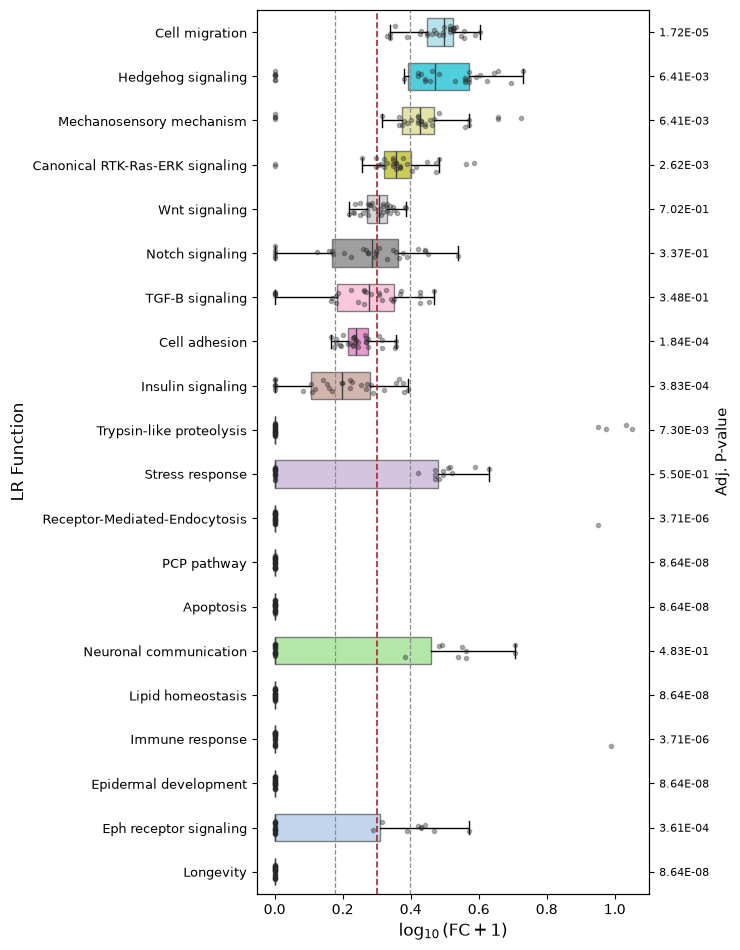

In [13]:
fold_changes = fractions.div(background, axis=0)
plot_order = enrichment.index[::-1]
values = [np.log10(fold_changes.loc[f].values + 1) for f in plot_order]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(plot_order) + 1.2))
colours = plt.get_cmap('tab20')(np.linspace(0, 1, len(plot_order)))
bp = ax.boxplot(values, vert=False, patch_artist=True, widths=0.62,
                medianprops=dict(color='0.25'), flierprops=dict(marker=''))
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour); patch.set_alpha(0.75); patch.set_edgecolor('0.35')

rng_jitter = np.random.default_rng(0)
for i, v in enumerate(values, start=1):
    ax.scatter(v, i + rng_jitter.uniform(-0.16, 0.16, len(v)), s=9,
               color='0.15', alpha=0.35, zorder=3)

ax.axvline(np.log10(2), color='firebrick', ls='--', lw=1.2)          # fold change of 1
for fc in (0.5, 1.5):
    ax.axvline(np.log10(fc + 1), color='0.55', ls='--', lw=0.9)
ax.set_yticks(range(1, len(plot_order) + 1)); ax.set_yticklabels(plot_order, fontsize=9)
ax.set_xlabel('$\\log_{10}(\\mathrm{FC}+1)$', fontsize=12)
ax.set_ylabel('LR Function', fontsize=12)

right = ax.twinx()
right.set_ylim(ax.get_ylim()); right.set_yticks(range(1, len(plot_order) + 1))
right.set_yticklabels(['{:.2E}'.format(enrichment.loc[f, 'adj_p']) for f in plot_order], fontsize=8)
right.set_ylabel('Adj. P-value', fontsize=11)
plt.tight_layout(); plt.show()

The red line is no enrichment; the grey lines mark fold changes of 0.5 and 1.5. Functions whose
boxes sit entirely at 0 were never chosen by any execution — strongly *depleted*, and the Wilcoxon
reports them as such rather than as absent evidence.

Two things to keep in mind when reading this:

- **It is conditioned on the curated annotation.** A function with one or two pairs in the whole
  list cannot show a stable fold change, and its p-value reflects consistency across executions
  rather than strength of evidence about biology.
- **Depletion is a real result here**, not a failure to detect. A function that the search reliably
  drops is one whose pairs do not help explain physical distance — which is informative given that
  the background is the curated list someone assembled as plausible.

## Notes

- **`pygad` is not `pyevolve`**, the seeds differ, and the published set is one run of many, so the
  numbers will not match exactly. The reproducible core is what should agree, and does.
- **Why the PPI table gets doubled.** Bray-Curtis is *undirected*: both interacting cells contribute
  ligands and receptors, so every interaction has to be available in either direction.
  `bidirectional_ppi_with_index` builds that doubled table once, when the objective is created, and
  records which interaction each row came from. Self-interactions are the exception -- a protein
  pairing with itself yields the same directed row twice, and keeping both would weight it double,
  so duplicates are dropped.
- **What the search actually varies.** A candidate is one bit per *interaction*, over the undirected
  pool. Expanding it to the doubled table is a single gather through that recorded provenance, so
  the table is never rebuilt per candidate and the ordering cannot drift. Both directed rows of a
  selected interaction get the same weight; a selected self-interaction contributes one row, not two.
- **`deduplicate=True`** collapses an interaction with its reciprocal before the search, so an input
  listing both is not weighted twice as heavily as the rest. Pairs loaded with `load_ppi` are already
  deduplicated by `preprocess_ppi_data`, so it is a no-op here.
- **No multiprocessing.** The original distributed independent runs across cores; the vectorized
  objective makes one run fast enough that it is not needed.
- **`selection_masks` is indexed against `results['pool']`**, not against `selection_frequency`,
  which is sorted by frequency for reading. Pairing the sorted frame with the masks positionally is
  a silent misalignment.